**Heart Disease Prediction Using Machine Learning Techniques**

In [ ]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# 2. LOAD DATASET
df = pd.read_csv("heart_disease.csv")

print("First 5 rows of the dataset:")
print(df.head(), "\n")

print("Dataset Info:")
print(df.info(), "\n")

print("Missing values in each column:")
print(df.isnull().sum(), "\n")

First 5 rows of the dataset:
    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0   

In [4]:
# 3. HANDLE MISSING VALUES
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols), "\n")

# Fill numeric columns with median
for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Fill categorical columns with mode
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

Numeric columns: ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
Categorical columns: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status'] 



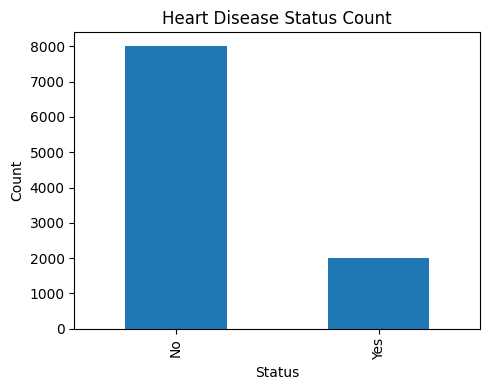

In [22]:
# 3A. VISUALIZATION: CLASS DISTRIBUTION
plt.figure(figsize=(5, 4))
df["Heart Disease Status"].value_counts().plot(kind="bar")
plt.title("Heart Disease Status Count")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

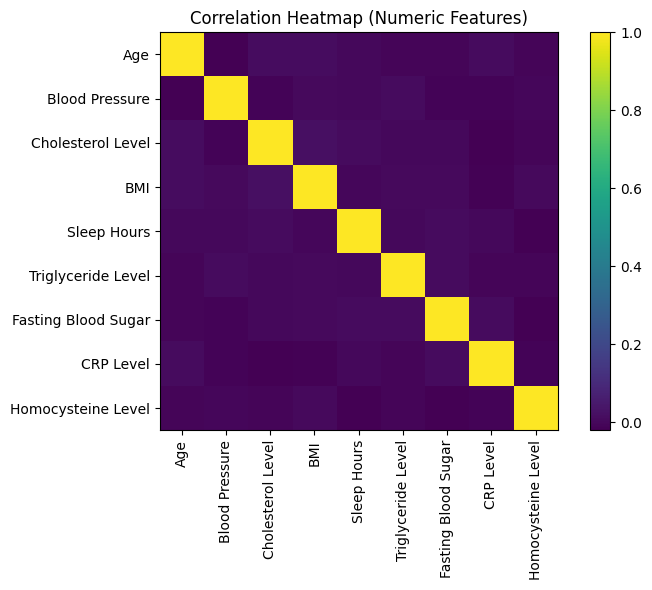

In [23]:
# 3B. VISUALIZATION: CORRELATION HEATMAP (NUMERIC FEATURES)
numeric_df = df[numeric_cols]
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation Heatmap (Numeric Features)")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [24]:
# 4. DEFINE FEATURES (X) AND TARGET (y)
target_col = "Heart Disease Status"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("Unique target values:", y.unique(), "\n")

Shape of X (features): (10000, 20)
Shape of y (target): (10000,)
Unique target values: ['No' 'Yes'] 



In [27]:
# 5. ENCODE CATEGORICAL FEATURES & TARGET
X_encoded = pd.get_dummies(X, drop_first=True)
print("Shape of X before encoding:", X.shape)
print("Shape of X after encoding:", X_encoded.shape, "\n")

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Target classes mapping (LabelEncoder):")
for idx, cls in enumerate(le.classes_):
    print(f"{cls} -> {idx}")
print("First 10 encoded target values:", y_encoded[:10], "\n")

Shape of X before encoding: (10000, 20)
Shape of X after encoding: (10000, 24) 

Target classes mapping (LabelEncoder):
No -> 0
Yes -> 1
First 10 encoded target values: [0 0 0 0 0 0 0 0 0 0] 



In [28]:
# 6. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   
)

print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape, "\n")

Train set shape: (8000, 24) (8000,)
Test set shape: (2000, 24) (2000,) 



In [29]:
# 7. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
# 8. MODEL EVALUATION FUNCTION
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}:- ")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred, zero_division=0), 4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

In [37]:
# 9. MODEL 1: LOGISTIC REGRESSION
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
evaluate_model("Logistic Regression", y_test, y_pred_log)


Logistic Regression:- 
Accuracy : 0.8
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Confusion Matrix:
 [[1600    0]
 [ 400    0]]

Classification Report:
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1600
         Yes       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



In [38]:
# 10. MODEL 2: K-NEAREST NEIGHBORS (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
evaluate_model("KNN (k=5)", y_test, y_pred_knn)


KNN (k=5):- 
Accuracy : 0.763
Precision: 0.13
Recall   : 0.0325
F1 Score : 0.052
Confusion Matrix:
 [[1513   87]
 [ 387   13]]

Classification Report:
              precision    recall  f1-score   support

          No       0.80      0.95      0.86      1600
         Yes       0.13      0.03      0.05       400

    accuracy                           0.76      2000
   macro avg       0.46      0.49      0.46      2000
weighted avg       0.66      0.76      0.70      2000



In [39]:
# 11. MODEL 3: RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, y_pred_rf)


Random Forest:- 
Accuracy : 0.8
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Confusion Matrix:
 [[1600    0]
 [ 400    0]]

Classification Report:
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1600
         Yes       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



In [43]:
# 12. COMPARE MODELS
print("\n\nMODEL COMPARISON (Accuracy & F1-Score):-")
models = {
    "Logistic Regression": y_pred_log,
    "KNN (k=5)": y_pred_knn,
    "Random Forest": y_pred_rf
}

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, zero_division=0)
    print(f"{name:20s} - Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")



MODEL COMPARISON (Accuracy & F1-Score):-
Logistic Regression  - Accuracy: 0.8000, F1-Score: 0.0000
KNN (k=5)            - Accuracy: 0.7630, F1-Score: 0.0520
Random Forest        - Accuracy: 0.8000, F1-Score: 0.0000


In [44]:
# 13. FEATURE IMPORTANCE (RANDOM FOREST)
importances = rf.feature_importances_
feature_names = X_encoded.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features (Random Forest):")
print(feature_importance_df.head(15))


Top 15 Important Features (Random Forest):
                     Feature  Importance
3                        BMI    0.095795
8         Homocysteine Level    0.094489
4                Sleep Hours    0.094357
7                  CRP Level    0.092879
5         Triglyceride Level    0.090938
2          Cholesterol Level    0.087430
6        Fasting Blood Sugar    0.083178
1             Blood Pressure    0.080806
0                        Age    0.079815
15   High Blood Pressure_Yes    0.015114
13  Family Heart Disease_Yes    0.015071
16   Low HDL Cholesterol_Yes    0.015002
14              Diabetes_Yes    0.014716
17  High LDL Cholesterol_Yes    0.014533
12               Smoking_Yes    0.014428


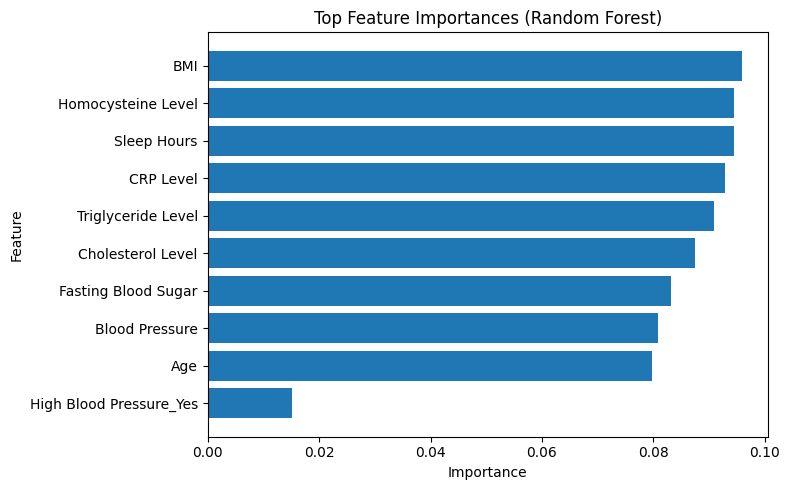

In [45]:
# 13A. VISUALIZATION: FEATURE IMPORTANCE BAR PLOT
top_n = 10
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

<Figure size 400x400 with 0 Axes>

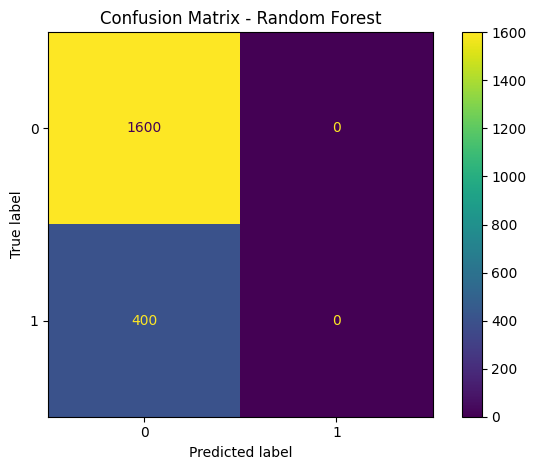

In [46]:
# 13B. VISUALIZATION: CONFUSION MATRIX FOR RANDOM FOREST
plt.figure(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [47]:
# 14. EXAMPLE PREDICTION
sample = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample)

sample_pred = rf.predict(sample_scaled)[0]
sample_pred_label = le.inverse_transform([sample_pred])[0]

print("\nExample Prediction for one test person:")
print("Sample row (encoded):")
print(sample)
print("\nModel prediction (Random Forest):", sample_pred, "->", sample_pred_label)


Example Prediction for one test person:
Sample row (encoded):
       Age  Blood Pressure  Cholesterol Level     BMI  Sleep Hours  \
6177  63.0           130.0              234.0  38.078     8.860326   

      Triglyceride Level  Fasting Blood Sugar  CRP Level  Homocysteine Level  \
6177               284.0                120.0   6.762998           15.550978   

      Gender_Male  ...  Diabetes_Yes  High Blood Pressure_Yes  \
6177         True  ...          True                     True   

      Low HDL Cholesterol_Yes  High LDL Cholesterol_Yes  \
6177                    False                      True   

      Alcohol Consumption_Low  Alcohol Consumption_Medium  Stress Level_Low  \
6177                     True                       False              True   

      Stress Level_Medium  Sugar Consumption_Low  Sugar Consumption_Medium  
6177                False                  False                     False  

[1 rows x 24 columns]

Model prediction (Random Forest): 0 -> No
